# Overnight effect — walkthrough

One of the simplest documented anomalies: **almost all of SPY's return has accrued overnight** (close to next open), while the regular session is roughly flat. The strategy is one sentence — buy at the close, sell at the open. Mirrors `scripts/run_overnight.py`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import pandas as pd
import matplotlib.pyplot as plt

from quantbt import metrics, plotting
from quantbt.strategies.overnight import overnight_returns, intraday_returns

## 1. Load SPY OHLC
We need the open as well as the close to separate the overnight and intraday moves.

In [2]:
ohlc = pd.read_csv('data/spy_ohlc.csv', index_col=0, parse_dates=True)
ohlc.tail(3)

,Open,High,Low,Close
Date,,,,
2024-12-26,589.409389,592.339211,588.013307,591.218445
2024-12-27,587.482441,587.718452,580.816590,584.995056
2024-12-30,577.994812,581.779985,574.573345,578.319214


## 2. Decompose the return
Split total (close-to-close) return into its overnight and intraday pieces.

In [3]:
overnight = overnight_returns(ohlc)
intraday = intraday_returns(ohlc)
buy_hold = ohlc['Close'].pct_change()

pd.DataFrame({
    'buy_hold': metrics.summarize(buy_hold),
    'intraday': metrics.summarize(intraday),
    'overnight': metrics.summarize(overnight),
}).T.round(3)

,ann_return,ann_vol,sharpe,sortino,max_drawdown,hit_rate
buy_hold,0.103,0.190,0.612,0.861,-0.552,0.551
intraday,0.020,0.146,0.211,0.290,-0.467,0.537
overnight,0.081,0.114,0.739,1.013,-0.294,0.554


Nearly all the return — and a better Sharpe with half the drawdown — lives in the overnight window; the intraday session is almost uncompensated risk.

## 3. The strategy, after costs
One round-trip per day. SPY's real round-trip is well under 1bp; the sweep shows how sensitive the result is.

In [4]:
sweep = {f'{b:g}bp': metrics.summarize(overnight - b*1e-4) for b in (0.0, 0.5, 1.0, 2.0)}
pd.DataFrame(sweep).T[['ann_return', 'sharpe', 'max_drawdown']].round(3)

,ann_return,sharpe,max_drawdown
0bp,0.081,0.739,-0.294
0.5bp,0.067,0.629,-0.295
1bp,0.054,0.518,-0.296
2bp,0.028,0.297,-0.298


## 4. Tearsheet (net of ~1bp/day)

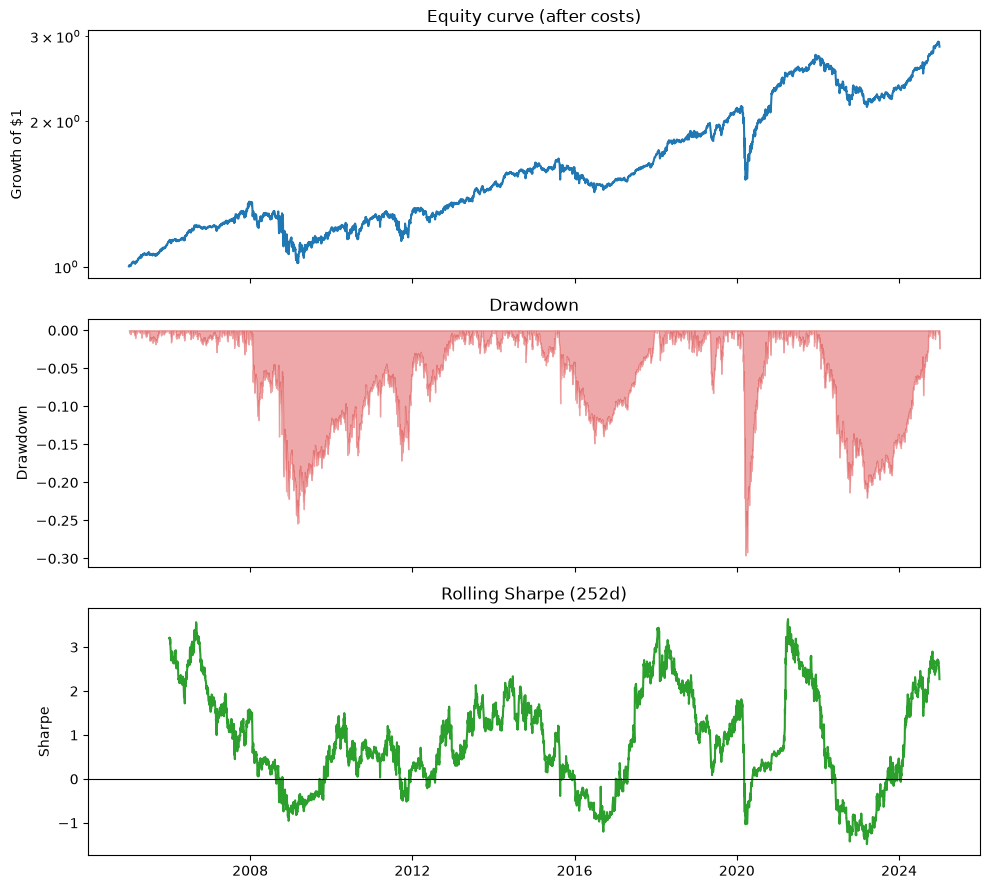

In [5]:
net = (overnight - 1e-4).dropna()
equity = (1 + net).cumprod()
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plotting.plot_equity(equity, ax=axes[0])
plotting.plot_drawdown(equity, ax=axes[1])
plotting.plot_rolling_sharpe(net, ax=axes[2])
fig.tight_layout()

## Takeaway
A simple, well-documented regularity: the index's drift is overwhelmingly an overnight phenomenon. It's not a high Sharpe — net of a realistic sub-1bp SPY round-trip it's roughly buy-and-hold's, but with far smaller drawdowns. The value is the clean decomposition and the one-sentence thesis, not a headline number. Caveats: overnight gap risk, and you can't trade exactly at the official close/open prints.